# Stock Market Forecasting

There is a large amount of unpredictablity in the stock market but also a wealth of data available that, as data enthusiasts, it is only natural for us to uncover hidden patterns in the market using this data. In this notebook, we aim to develop time-series models to try and forecast and predict stock prices in future time periods. For this notebook, we choose to perform a deep dive on Nike (NKE). We first focus on traditional time-series statistical models and then we look at using ML models and compare performance between our various methods.

In [1]:
!pip install --upgrade mplfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import mplfinance as mpf
from statsmodels.tsa import stattools as tsast
import matplotlib.pyplot as plt
import tensorflow as tf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print("Example path name: ", os.path.join(dirname, filename))
        break
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Example path name:  /kaggle/input/price-volume-data-for-all-us-stocks-etfs/Stocks/ufi.us.txt
Example path name:  /kaggle/input/price-volume-data-for-all-us-stocks-etfs/ETFs/djci.us.txt
Example path name:  /kaggle/input/price-volume-data-for-all-us-stocks-etfs/Data/Stocks/ufi.us.txt
Example path name:  /kaggle/input/price-volume-data-for-all-us-stocks-etfs/Data/ETFs/djci.us.txt


In [3]:
nke = pd.read_csv('/kaggle/input/price-volume-data-for-all-us-stocks-etfs/Stocks/nke.us.txt', index_col=0)
# spy = pd.read_csv('/kaggle/input/price-volume-data-for-all-us-stocks-etfs/ETFs/spy.us.txt')
nke.index = pd.to_datetime(nke.index)
nke = nke.drop(['OpenInt'],1)
nke

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  after removing the cwd from sys.path.


,Open,High,Low,Close,Volume
Date,,,,,
1987-08-19,0.24563,0.24793,0.23872,0.24337,13249179
1987-08-20,0.24337,0.24793,0.24337,0.24563,13869472
1987-08-21,0.24793,0.24793,0.24337,0.24563,2780866
1987-08-24,0.24337,0.24563,0.24337,0.24337,12754334
1987-08-25,0.24104,0.27093,0.24104,0.26389,31767365
...,...,...,...,...,...
2017-11-06,55.29000,56.13000,55.14000,56.04000,9241026
2017-11-07,55.75000,56.01500,55.02000,55.15000,7364880
2017-11-08,55.00000,55.77000,54.89000,55.76000,7078567


In [4]:
nke.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7620 entries, 1987-08-19 to 2017-11-10
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    7620 non-null   float64
 1   High    7620 non-null   float64
 2   Low     7620 non-null   float64
 3   Close   7620 non-null   float64
 4   Volume  7620 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 357.2 KB


In [5]:
nke.describe()

,Open,High,Low,Close,Volume
count,7620.000000,7620.000000,7620.000000,7620.000000,7.620000e+03
mean,13.502061,13.636573,13.370140,13.507623,1.381346e+07
std,16.130188,16.256137,16.000816,16.131066,1.136338e+07
min,0.179050,0.183640,0.167540,0.179050,0.000000e+00
25%,2.095400,2.118350,2.075300,2.098300,7.634038e+06
50%,6.480600,6.568100,6.407800,6.489300,1.076627e+07
75%,16.152250,16.345250,15.985750,16.178000,1.587077e+07
max,66.650000,66.725000,65.069000,65.559000,1.714578e+08


In [6]:
tsast.acovf(nke['Open'])


array([ 2.60148823e+02,  2.59968986e+02,  2.59794461e+02, ...,
       -2.18980971e-01, -1.46800363e-01, -7.37244382e-02])

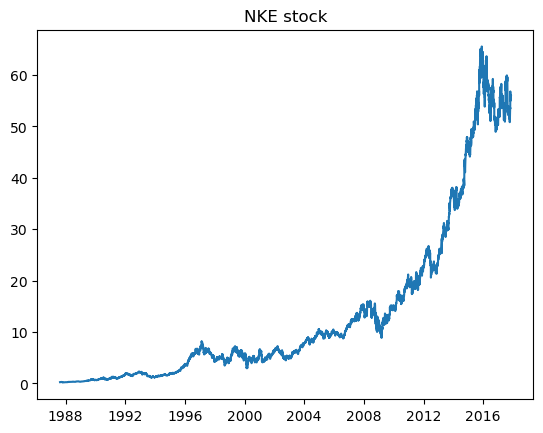

In [7]:
nke_day = nke["Close"].asfreq('D').interpolate()

plt.plot(nke_day)
plt.title('NKE stock')
plt.show()

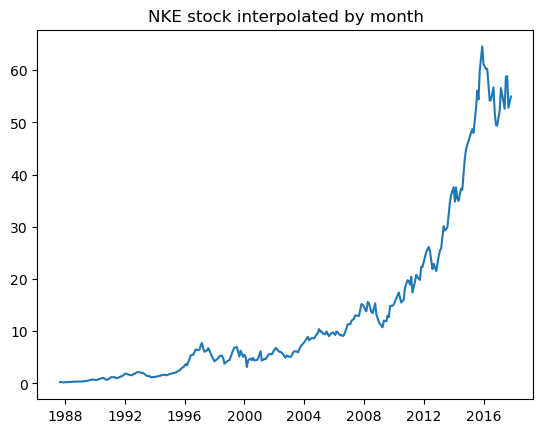

In [8]:
nke_month = nke["Close"].asfreq('M').interpolate()
plt.plot(nke_month)
plt.title('NKE stock interpolated by month')
plt.show()

# Autocorrelation 

Autocorrelation - Measuring the linear dependence between a given time point $x_t$ and a lagged time points $x_{t+h}$, where $t$ denotes the time index and $h$ is the amount of lag. [1]

Text(0, 0.5, 'Autocovariance')

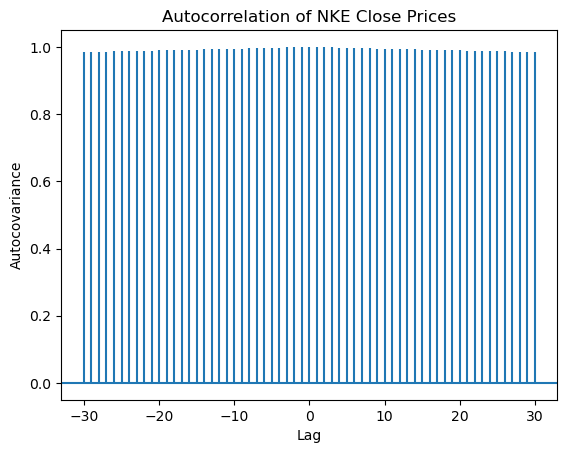

In [9]:
plt.acorr(nke['Close'], maxlags = 30)
plt.title('Autocorrelation of NKE Close Prices')
plt.xlabel('Lag')
plt.ylabel('Autocovariance')

Text(0, 0.5, 'Autocovariance')

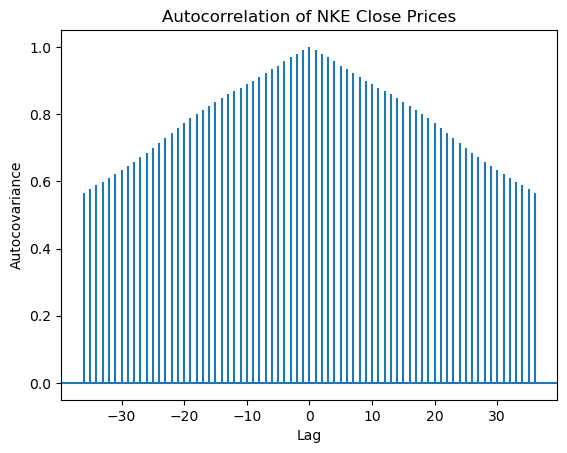

In [10]:
plt.acorr(nke_month, maxlags = 36)
plt.title('Autocorrelation of NKE Close Prices')
plt.xlabel('Lag')
plt.ylabel('Autocovariance')

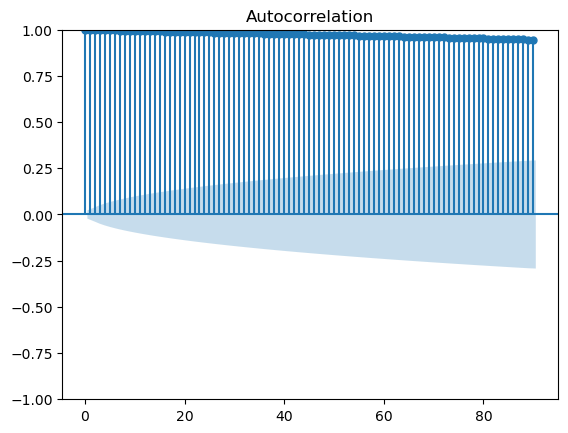

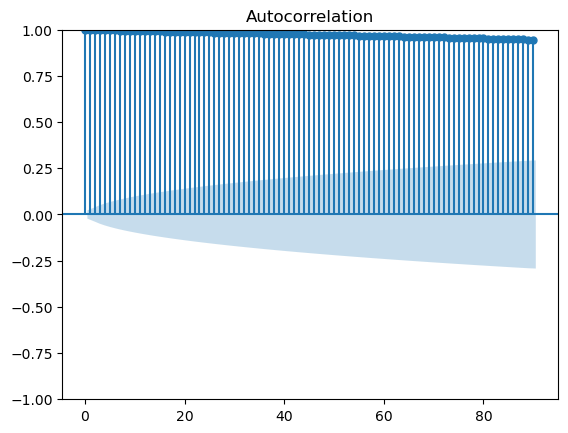

In [11]:
plot_acf(nke['Close'], lags=90)

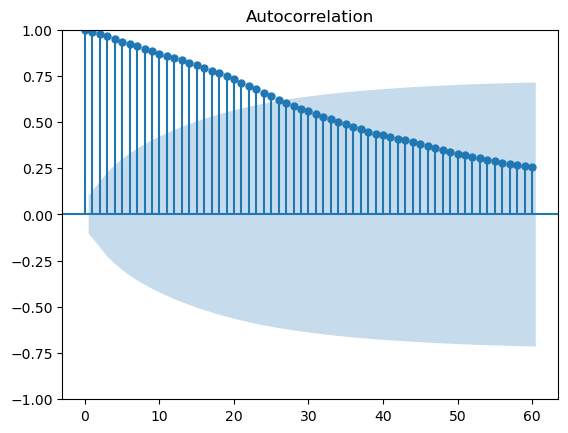

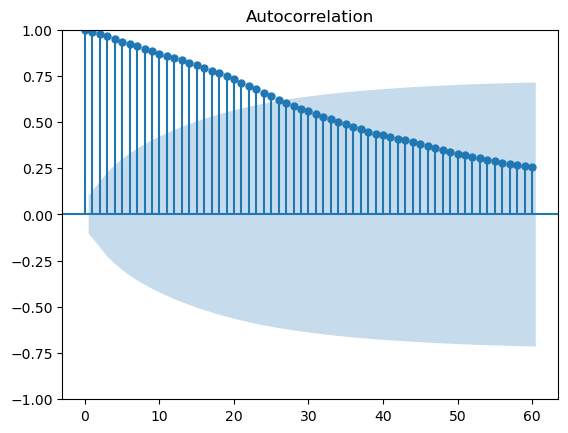

In [12]:
plot_acf(nke_month, lags=60)

Autocorrelation seems to exist within the series for lags of below 2 years. After that, the autocorrelation becomes statistically insignificant. However, we can confidently see that each time point is affected by each data point before it, with the effect waning as the lag increases.

Partial autocorrelation explains the correlation between two time series data points ignoring the effect of the time series data points between them. 

/opt/conda/lib/python3.7/site-packages/statsmodels/graphics/tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


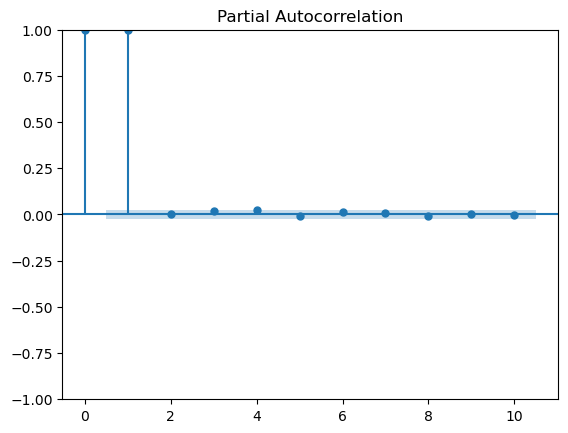

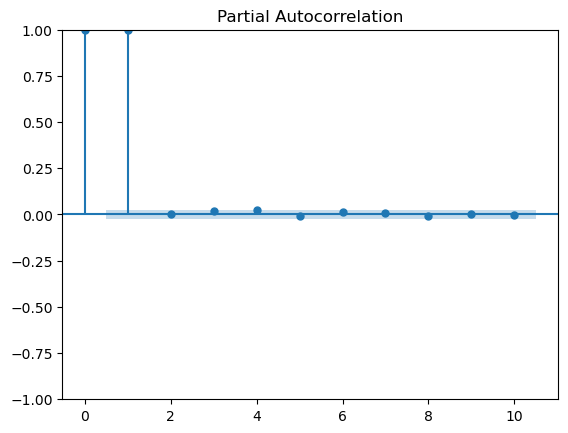

In [13]:
plot_pacf(nke['Close'], lags = 10)

# Detrending the Data

## Why use detrending?
 Detrending helps us recognize patterns in the noise. By modeling with different trends, it also helps us realize what type of the pattern of the underlying trend.

## Detrending using Percentage Difference

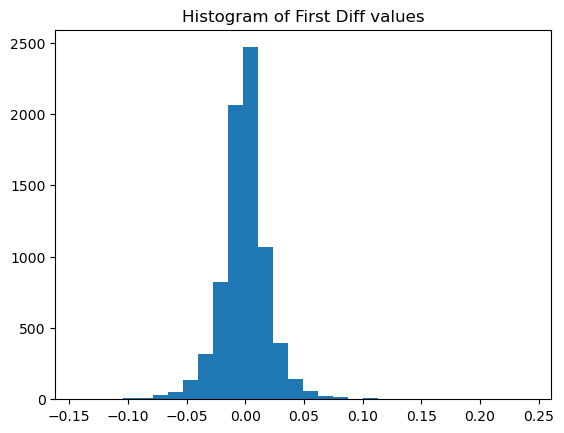

In [14]:
nke['NormalizedFirstDiffClose'] = (nke['Close'] - nke['Close'].shift(-1))/(nke['Close'].shift(-1))
nke['FirstDiffClose']= (nke['Close'] - nke['Close'].shift(-1))
hist, bins = np.histogram(nke['NormalizedFirstDiffClose'].dropna(), bins = 30)
plt.hist(nke['NormalizedFirstDiffClose'], bins=30)
plt.title('Histogram of First Diff values')
plt.show()

In [15]:
tsast.adfuller(nke['FirstDiffClose'].dropna())

(-15.619670429840946,
 1.738261703919123e-28,
 35,
 7583,
 {'1%': -3.431212655283814,
  '5%': -2.8619212289398046,
  '10%': -2.566972923702211},
 3749.967584576707)

Detrending using first difference allows us to see a statistically strong sign of stationary within the detrended data.

## Detrending using Linear Regression Model

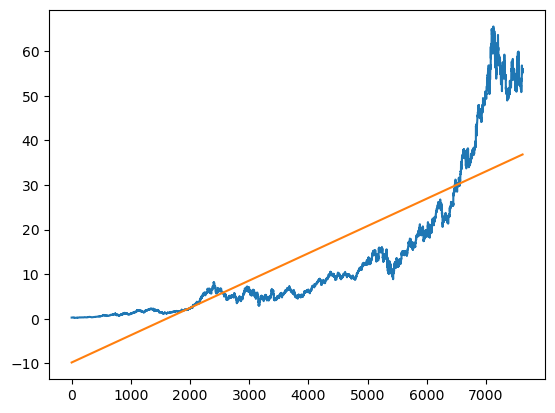

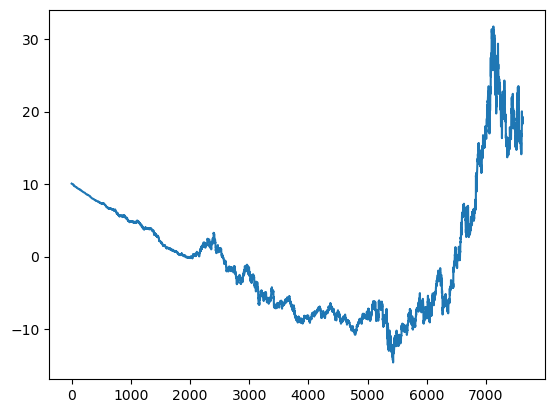

In [16]:
model = LinearRegression()
X = [i for i in range(0, len(nke))]
X = np.reshape(X, (-1, 1))

y = nke['Close'].dropna().values.reshape(-1, 1)
model.fit(X,y)
trend = model.predict(X)
plt.plot(y)
plt.plot(trend)
plt.show()
lin_detrended = [y[i]-trend[i] for i in range(0, len(nke))]
plt.plot(lin_detrended)
plt.show()

We run an Augmented Dickey Fuller test to test for stationarity after detrending [3].

In [17]:
tsast.adfuller(lin_detrended)

(-0.4917858558110334,
 0.8936094886744061,
 36,
 7583,
 {'1%': -3.431212655283814,
  '5%': -2.8619212289398046,
  '10%': -2.566972923702211},
 3751.211277775017)

Let us try using another detrending method, as the linear trend doesn't seem to do well.

## Detrending using Exponential Model

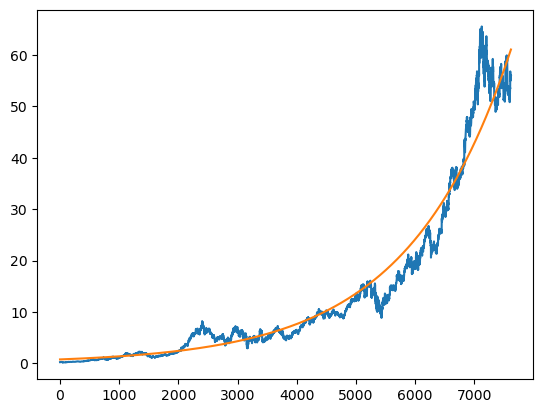

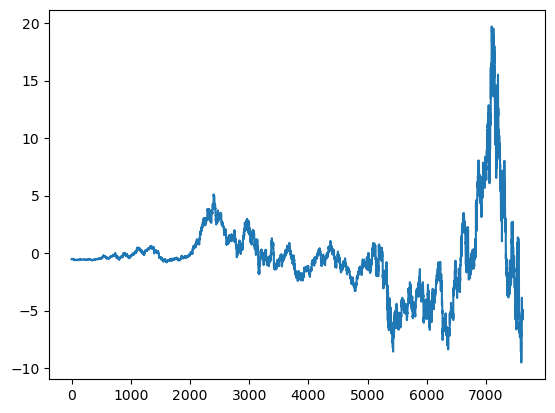

In [18]:
X = [i for i in range(0, len(nke))]
X = np.reshape(X, (-1, ))
y = nke['Close'].dropna().values.reshape(-1, )

expfit = np.polyfit(X, np.log(y), 1, w=np.sqrt(y))
plt.plot(y)
exp_trend = np.exp(expfit[1])*np.exp(expfit[0] * X)
plt.plot(exp_trend)
plt.show()
nke_exp_detrended = [y[i]-exp_trend[i] for i in range(0, len(nke))]
plt.plot(nke_exp_detrended)
plt.show()

In [19]:
print('Augmented Dickey Fuller')
tsast.adfuller(nke_exp_detrended)

Augmented Dickey Fuller


(-3.0244459950437825,
 0.032673664046528154,
 36,
 7583,
 {'1%': -3.431212655283814,
  '5%': -2.8619212289398046,
  '10%': -2.566972923702211},
 3737.1875500999868)

There is a statisically significant exponential trend existing within the data.

# Smoothing

## Moving Average

Moving average indicators are used in stock technical analysis to determine when to buy or sell stock [2]. By taking the average of the prices over a time period, we are able to reduce the noise on a chart while observing the direction the price is moving. 

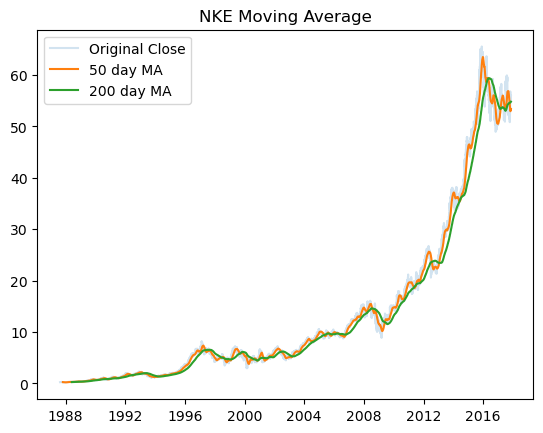

In [20]:
nke['Close_mov_avg_50'] = nke['Close'].rolling(50).mean()
nke['Close_mov_avg_200'] = nke['Close'].rolling(200).mean()
plt.plot(nke['Close'], label='Original Close', alpha = 0.2)
plt.plot(nke['Close_mov_avg_50'].dropna(), label = '50 day MA')
plt.plot(nke['Close_mov_avg_200'].dropna(), label = '200 day MA')
plt.legend()
plt.title('NKE Moving Average')
plt.show()

There is a very clear uptrend in the stock after 2008. This momentum may have been used as a signal to buy during the time.

# Decomposition

Close, additive decomposition, month frequency


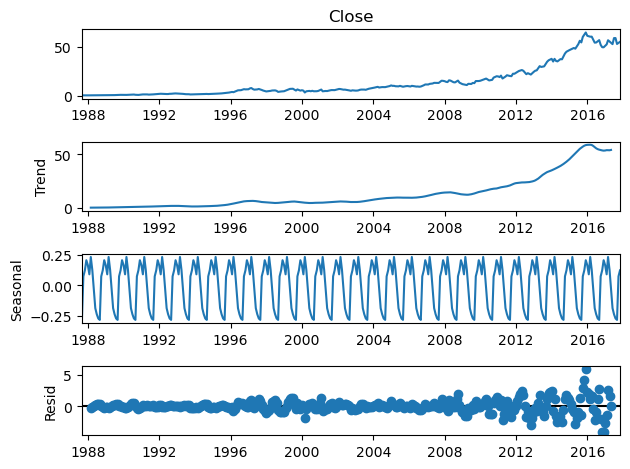

In [21]:
result=seasonal_decompose(nke_month, model='additive', period=12).plot()
print('Close, additive decomposition, month frequency')

Close, multiplicable decomposition, month frequency


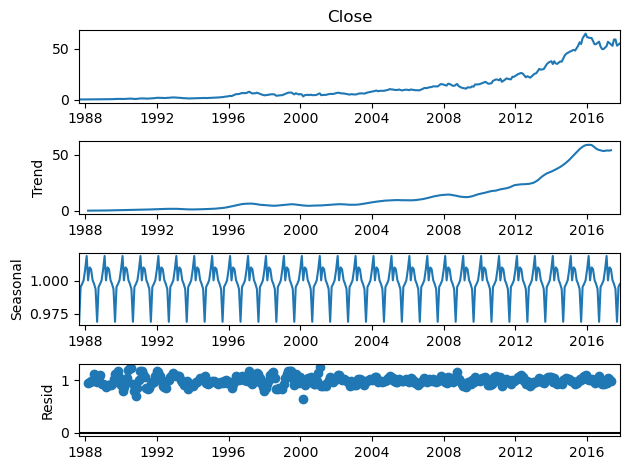

In [22]:
result=seasonal_decompose(nke_month, model='multiplicable', period=12).plot()
print('Close, multiplicable decomposition, month frequency')

Close, additive decomposition, day frequency


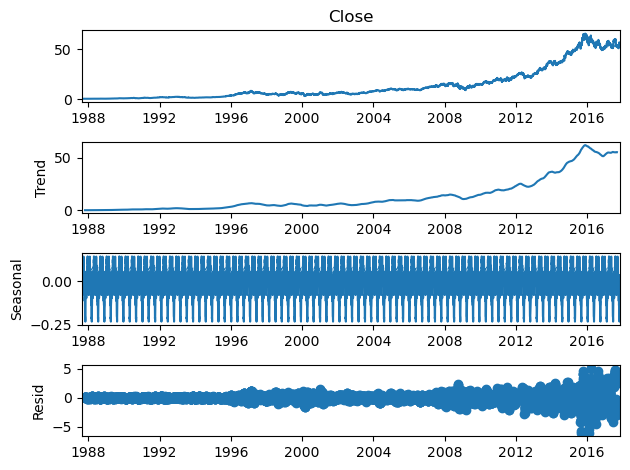

In [23]:
result=seasonal_decompose(nke['Close'], model='additive', period=90).plot()
print('Close, additive decomposition, day frequency')

Close, additive decomposition, day frequency


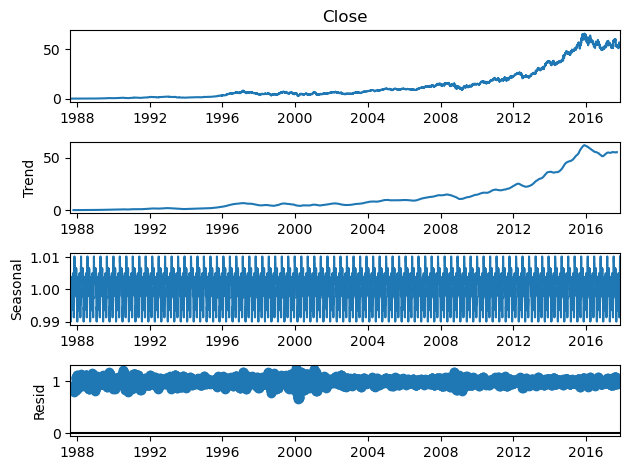

In [24]:
result = seasonal_decompose(nke['Close'], model='multiplicable', period=90).plot()
print('Close, additive decomposition, day frequency')

From the plots above, we can see the data has minimal seasonality effects and is mostly driven by uptrend momentum. By detrending the data, we can see the residuals stay consistent around 1, suggesting that this data is trend-stationary.

# ARIMA Model

In [25]:
model=ARIMA(nke['FirstDiffClose'],order=(2,1,0))
result=model.fit()

/opt/conda/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [26]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:         FirstDiffClose   No. Observations:                 7620
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -3158.229
Date:                Sat, 18 Mar 2023   AIC                           6322.458
Time:                        07:30:32   BIC                           6343.273
Sample:                             0   HQIC                          6329.600
                               - 7620                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6466      0.003   -197.948      0.000      -0.653      -0.640
ar.L2         -0.3258      0.004    -85.564      0.000      -0.333      -0.318
sigma2         0.1341      0.001    259.711      0.000       0.133       0.135
===================================================================================
Ljung-Box (L1) (Q):                  54.82   Jarque-Bera (JB):            358910.89
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):              77.02   Skew:                            -1.24
Prob(H) (two-sided):                  0.00   Kurtosis:                        36.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<AxesSubplot:xlabel='Date'>

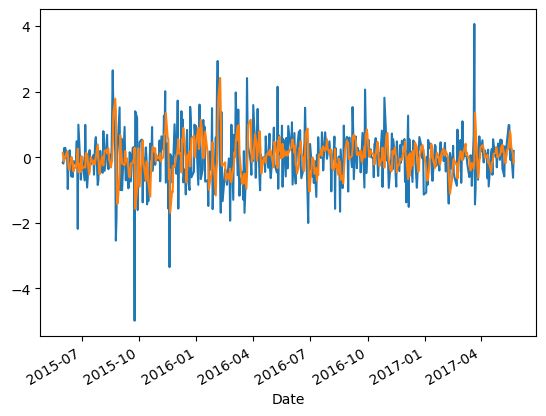

In [27]:
nke['FirstDiffClose'][7000:7500].plot()
result.predict(start=7000, end=7499).plot()

<AxesSubplot:xlabel='Date'>

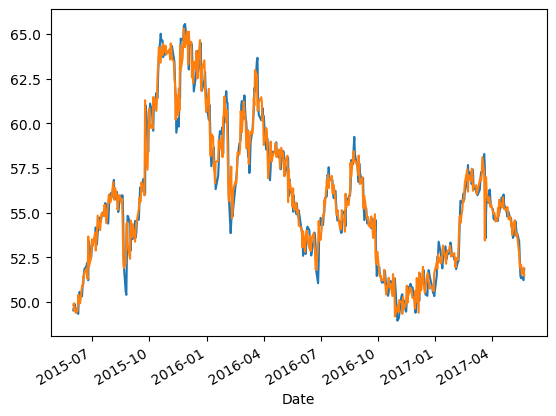

In [28]:
(nke['Close'].shift(-1)+ nke['FirstDiffClose'])[7000:7500].plot()
(nke['Close'].shift(-1)[7000:7500]+result.predict(start=7000, end=7499)).plot()

In [29]:
rmse = math.sqrt(mean_squared_error(nke['FirstDiffClose'][6000:7000].values, result.predict(start=6000, end=6999)))
print("The root mean squared error is {}.".format(rmse))

The root mean squared error is 0.5118333873883476.


We can see that the ARIMA model with second degree autoregression, first degree differencing and zero degree moving average works well. Increasing the moving average degree does not change the performance of the model much.

# LSTM

LSTMs are a type of recurrent neural network (RNN), which are machine learning models specially suited for sequential data by having data from previous periods affect calculations for future predictions. LSTMs are special in that they account for long-term dependencies, which vanilla RNNs are ill-suited for. LSTMs can be especially useful for time-series data to forecast future values.

We look at using LSTMs to predict stock prices. We preprocess our data below, using a window length of 90.

In [30]:
nke = pd.read_csv('/kaggle/input/price-volume-data-for-all-us-stocks-etfs/Stocks/nke.us.txt', index_col=0)
# spy = pd.read_csv('/kaggle/input/price-volume-data-for-all-us-stocks-etfs/ETFs/spy.us.txt')
nke.index = pd.to_datetime(nke.index)
nke = nke.drop(['OpenInt'],1)
nke_ts = tf.convert_to_tensor(nke)
nke_ds = tf.data.Dataset.from_tensors(nke_ts)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  after removing the cwd from sys.path.


In [31]:
from sklearn.preprocessing import MinMaxScaler
window_len = 90
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(nke.filter(['Close']).values)
train_data = scaled_data[0:int(0.7*len(nke)), :]
val_data = scaled_data[int(0.7*len(nke)): int(0.9*len(nke)), :]
test_data = scaled_data[int(0.9*len(nke)): , :]
x_train = []
x_val = []
y_train = []
y_val = []
x_test = []
y_test = nke.filter(['Close']).values[int(0.9*len(nke)): ,:]

for i in range(window_len, len(train_data)):
    x_train.append(train_data[i-window_len:i, 0])
    y_train.append(train_data[i, 0])
    
for i in range(window_len, len(val_data)):
    x_val.append(val_data[i-window_len:i, 0])
    y_val.append(val_data[i, 0])
    
for i in range(window_len, len(test_data)):
    x_test.append(test_data[i-window_len:i, 0])
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)
x_val, y_val = np.array(x_val), np.array(y_val)
x_test = np.array(x_test)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_val =np.reshape(x_val, (x_val.shape[0], x_val.shape[1], 1))
x_test =np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
# x_train.shape

In [32]:
def create_and_fit_lstm_model(lstm_units:list = [16],epochs = 50, lr:float = 0.0008, stacked:bool = False):
#     early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
#                                                         patience=6,
#                                                         mode='min')
    
    if stacked:
        lstm_model = tf.keras.models.Sequential([
        # Shape [batch, time, features] => [batch, time, lstm_units]
        tf.keras.layers.LSTM(lstm_units[0], return_sequences=True),
        tf.keras.layers.LSTM(lstm_units[1], return_sequences=False),
        # Shape => [batch, time, features]
        tf.keras.layers.Dense(units=1)
    ])
    else:
        lstm_model = tf.keras.models.Sequential([
            # Shape [batch, time, features] => [batch, time, lstm_units]
            tf.keras.layers.LSTM(lstm_units[0], return_sequences=False),
            # Shape => [batch, time, features]
            tf.keras.layers.Dense(units=1)
        ])
    
    
    lstm_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    metrics=[tf.keras.metrics.MeanAbsoluteError()])
    ## The default learning rate undervalued the predicted price. But increasing it decreased MSE.
    history = lstm_model.fit(x_train, y_train,validation_data = (x_val, y_val),
                         epochs=epochs)
    return history, lstm_model

In [33]:
def evaluate_ts_model(history, model, test_data, true_data):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.show()
    
    predict = model.predict(test_data)
    predict = scaler.inverse_transform(predict)
    plt.plot(true_data[int(0.9*len(nke))+window_len: , :], label = 'True')
    plt.plot(predict, label = 'Predicted')
    plt.legend()
    plt.show()
    MSE = math.sqrt(mean_squared_error(true_data[int(0.9*len(nke))+window_len: , :], predict))
    print(f'The Mean Squared Error is: {MSE}')

### Single LSTM Layer

In [34]:
history, lstm_model = create_and_fit_lstm_model()

Epoch 1/50
164/164 [==============================] - 9s 36ms/step - loss: 0.0011 - mean_absolute_error: 0.0183 - val_loss: 2.6426e-04 - val_mean_absolute_error: 0.0124
Epoch 2/50
164/164 [==============================] - 6s 34ms/step - loss: 2.2833e-05 - mean_absolute_error: 0.0034 - val_loss: 4.9862e-04 - val_mean_absolute_error: 0.0147
Epoch 3/50
164/164 [==============================] - 6s 34ms/step - loss: 1.9352e-05 - mean_absolute_error: 0.0029 - val_loss: 0.0011 - val_mean_absolute_error: 0.0224
Epoch 4/50
164/164 [==============================] - 6s 34ms/step - loss: 1.8745e-05 - mean_absolute_error: 0.0028 - val_loss: 9.5615e-04 - val_mean_absolute_error: 0.0207
Epoch 5/50
164/164 [==============================] - 6s 36ms/step - loss: 1.8409e-05 - mean_absolute_error: 0.0029 - val_loss: 0.0013 - val_mean_absolute_error: 0.0258
Epoch 6/50
164/164 [==============================] - 6s 34ms/step - loss: 1.7647e-05 - mean_absolute_error: 0.0027 - val_loss: 9.4100e-04 - val_me

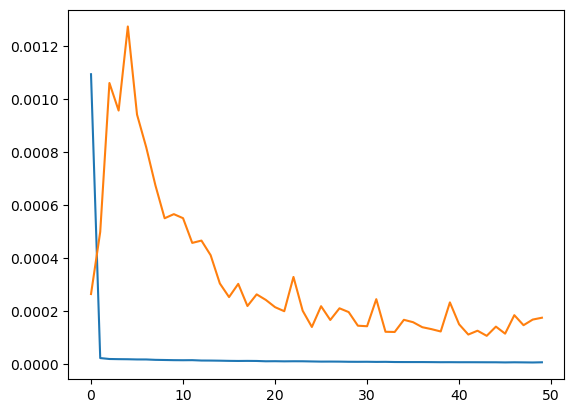

21/21 [==============================] - 1s 9ms/step


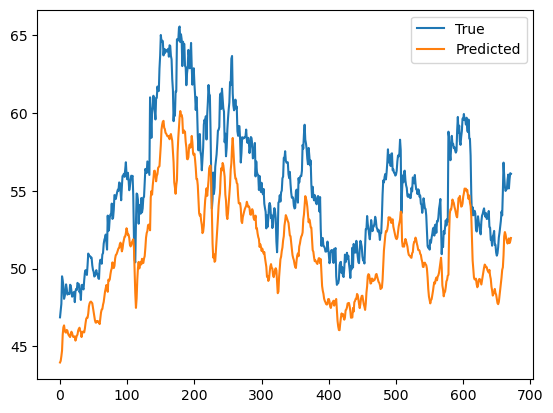

The Mean Squared Error is: 4.030187547784554


In [35]:
evaluate_ts_model(history, lstm_model, x_test,nke.filter(['Close']).values )

### Increasing LSTM Units

In [36]:
history, model = create_and_fit_lstm_model(lstm_units = [90], stacked= False)

Epoch 1/50
164/164 [==============================] - 12s 59ms/step - loss: 2.6962e-04 - mean_absolute_error: 0.0072 - val_loss: 1.2663e-04 - val_mean_absolute_error: 0.0083
Epoch 2/50
164/164 [==============================] - 9s 57ms/step - loss: 1.6412e-05 - mean_absolute_error: 0.0026 - val_loss: 1.2079e-04 - val_mean_absolute_error: 0.0083
Epoch 3/50
164/164 [==============================] - 9s 58ms/step - loss: 1.5581e-05 - mean_absolute_error: 0.0026 - val_loss: 1.2532e-04 - val_mean_absolute_error: 0.0083
Epoch 4/50
164/164 [==============================] - 9s 57ms/step - loss: 1.5321e-05 - mean_absolute_error: 0.0026 - val_loss: 1.5272e-04 - val_mean_absolute_error: 0.0093
Epoch 5/50
164/164 [==============================] - 9s 57ms/step - loss: 1.4713e-05 - mean_absolute_error: 0.0026 - val_loss: 2.6090e-04 - val_mean_absolute_error: 0.0127
Epoch 6/50
164/164 [==============================] - 9s 57ms/step - loss: 1.3347e-05 - mean_absolute_error: 0.0024 - val_loss: 1.4758

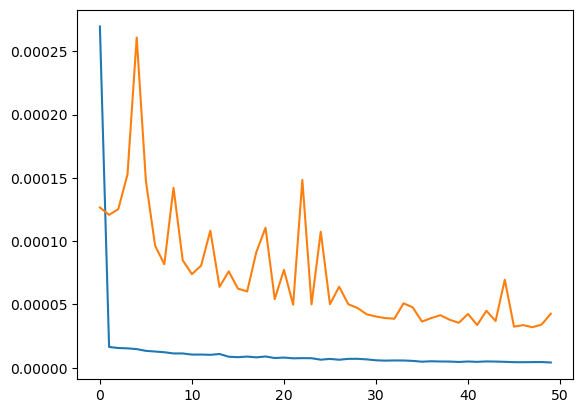

21/21 [==============================] - 1s 20ms/step


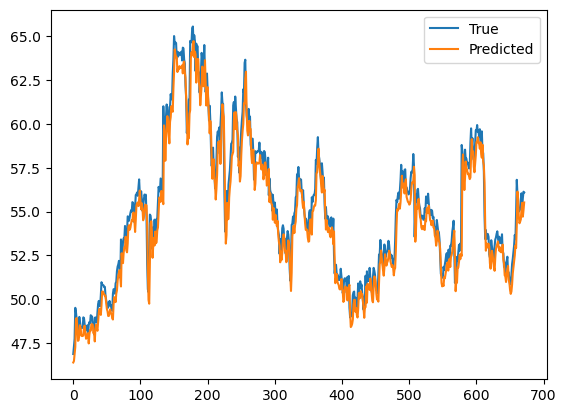

The Mean Squared Error is: 1.004292921470345


In [37]:
evaluate_ts_model(history, model, x_test,nke.filter(['Close']).values )

### Stacked LSTM Layers

#### 32 units in first layer, 32 in second layer

In [38]:
history, lstm_model_stacked = create_and_fit_lstm_model(lstm_units = [32, 32],stacked= True)

Epoch 1/50
164/164 [==============================] - 18s 87ms/step - loss: 2.1091e-04 - mean_absolute_error: 0.0069 - val_loss: 1.2810e-04 - val_mean_absolute_error: 0.0084
Epoch 2/50
164/164 [==============================] - 13s 80ms/step - loss: 1.7240e-05 - mean_absolute_error: 0.0027 - val_loss: 1.9302e-04 - val_mean_absolute_error: 0.0103
Epoch 3/50
164/164 [==============================] - 13s 81ms/step - loss: 1.6432e-05 - mean_absolute_error: 0.0027 - val_loss: 2.6852e-04 - val_mean_absolute_error: 0.0124
Epoch 4/50
164/164 [==============================] - 13s 82ms/step - loss: 1.6512e-05 - mean_absolute_error: 0.0027 - val_loss: 1.8230e-04 - val_mean_absolute_error: 0.0099
Epoch 5/50
164/164 [==============================] - 14s 88ms/step - loss: 1.6891e-05 - mean_absolute_error: 0.0028 - val_loss: 2.2016e-04 - val_mean_absolute_error: 0.0109
Epoch 6/50
164/164 [==============================] - 14s 85ms/step - loss: 1.5509e-05 - mean_absolute_error: 0.0026 - val_loss: 1

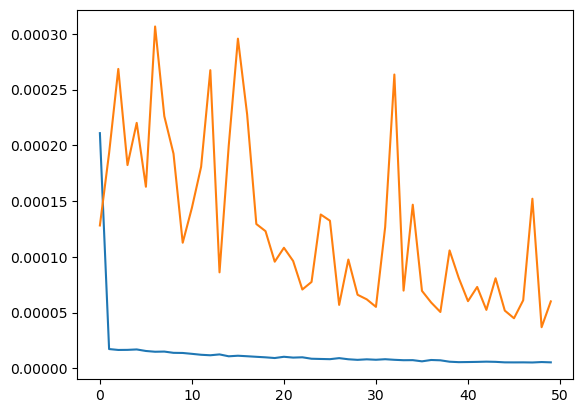

21/21 [==============================] - 1s 20ms/step


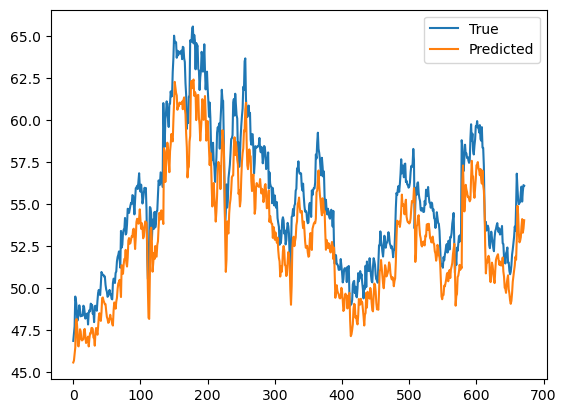

The Mean Squared Error is: 2.245718825538182


In [39]:
evaluate_ts_model(history, lstm_model_stacked, x_test,nke.filter(['Close']).values )

We see that a single layer LSTM performs well in predicting future stock price. Adding another LSTM layer does not seem to improve over the single layer LSTM model by much. 

# Conclusion

When dealing with stock data, we want to use time series techniques to find patterns within the stock data with the aim of predicting future values. We focused on NKE stock. We first looked at using autocorrelation, partial autocorrelation, and detrending methods to visualize the different patterns within our data. We then experimented with the ARIMA and LSTM models to try and forecast the stock. Both of the models performed well, with the LSTM model performing slightly better. In the future, we will try our methods with different stock classes, and we will also experiment with different ML-based prediction methods like reinforcement learning.

# Resources

[1] Shumway, Robert H., and David S. Stoffer. Time Series Analysis and Its Applications: With R Examples. Springer, 2017. 

[2] Mitchell, Cory. How to Use a Moving Average to Buy Stocks. https://www.investopedia.com/articles/active-trading/052014/how-use-moving-average-buy-stocks.asp#toc-moving-average-length

[3] https://machinelearningmastery.com/time-series-data-stationary-python/

[4] https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network

[5] https://machinelearningmastery.com/stacked-long-short-term-memory-networks/